# ImageCLEF 2026 — Multimodal Reasoning OpenQA Visual

**Model:** [Qwen3-VL-8B-Instruct](https://huggingface.co/Qwen/Qwen3-VL-8B-Instruct) (9B params, BF16)
**Inference:** vLLM
**Hardware:** NUQ JupyterLab, 2× A100-80GB
**Task:** Image contains an exam question. Generate a free-form answer in the question's language.

## Why Qwen3-VL-8B?

- **Native 256K context, 32-language OCR** (covers all 6 dataset languages well)
- **Improved STEM/math reasoning** — directly helps the math-heavy dev split (22.5%)
- **DeepStack ViT fusion** — sharper layout/diagram understanding than Qwen2.5-VL
- **9B params in BF16 ≈ 18 GB** — fits on 1× A100-80GB, with TP=2 you have plenty of headroom

## Phase map
1. GPU check & paths
2. Install dependencies
3. Download dataset
4. Data exploration
5. Utilities (normalization, answer extraction)
6. Multilingual prompts
7. Load Qwen3-VL-8B with vLLM
8. Inference — zero-shot CoT baseline
9. Evaluate on dev (multi-metric, per-slice)
10. Self-consistency
11. Subject-specialized prompts
12. Build final submission

Run top-to-bottom. The model loads once in Phase 7 and is reused by Phases 8, 10, 11.


## Phase 1 — GPU check & paths


In [2]:
# 1.1 — GPU check & tensor-parallel size
import subprocess, os, sys
from pathlib import Path

print("Python:", sys.version.split()[0])
out = subprocess.check_output(
    ["nvidia-smi",
     "--query-gpu=index,name,memory.total,memory.free",
     "--format=csv,noheader,nounits"]
).decode()
print("\nGPUs:")
print(out)

n_gpus = len([ln for ln in out.strip().splitlines() if ln.strip()])
# 8B BF16 fits on 1 GPU; TP=2 if available for headroom & throughput
TENSOR_PARALLEL_SIZE = 2 if n_gpus >= 2 else 1
print(f">>> tensor_parallel_size = {TENSOR_PARALLEL_SIZE}")


Python: 3.12.5

GPUs:
0, NVIDIA A100-PCIE-40GB, 40960, 40443

>>> tensor_parallel_size = 1


In [3]:
# 1.2 — Project paths
PROJECT_ROOT = Path("./imageclef-mr2026").resolve()
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUTS = PROJECT_ROOT / "outputs"
HF_CACHE = Path(os.environ.get("HF_HOME", str(Path.home() / ".cache/huggingface")))

for d in (DATA_ROOT, OUTPUTS):
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("HF_CACHE    :", HF_CACHE)


PROJECT_ROOT: /projects/p32887/ImageClef/MultimodalReasoning/imageclef-mr2026
HF_CACHE    : /home/pmp6991/.cache/huggingface


## Phase 2 — Install dependencies

Run **once per kernel session**.

> **Important version notes for Qwen3-VL:**
> - `transformers>=4.57` (or build from source) — adds the `Qwen3VLForConditionalGeneration` class
> - `vllm>=0.10` — adds Qwen3-VL support
> - `qwen-vl-utils` ≥ 0.0.10 (for the new image processor budget API)


In [7]:
!pip install "vllm==0.7.3" --extra-index-url https://download.pytorch.org/whl/cu121

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 75.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 43.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 49.1 MB/s eta 0:00:00


  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 80.3 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 77.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 79.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 90.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 93.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 88.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 95.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 96.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 91.4 MB/s eta 0:0

INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of cupy-cuda12x to determine which version is compatible with other requirements. This could take a while.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.6/264.6 MB 41.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 48.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 76.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 36.3 MB/s eta 0:00:00
Using cached filelock-3.29.0-py3-none-any.whl (39 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 46.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 35.3 MB/s eta 0:00:00
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 88.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 959.8/959.8 kB 14.5 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [11]:
!pip install torch transformers

Defaulting to user installation because normal site-packages is not writeable


In [4]:
# 2.1 — Install. Uncomment the call to actually run.
import sys, subprocess

PIP_PACKAGES = [
    "vllm>=0.10",
    "transformers>=4.57.0",
    "accelerate>=0.34",
    "datasets>=3.0",
    "huggingface-hub>=0.26",
    "qwen-vl-utils[decord]>=0.0.10",
    "pillow", "pyarrow", "pandas", "numpy", "tqdm",
    "bert-score",
    "regex",
    "openai",
]

def pip_install(pkgs):
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + pkgs
    subprocess.check_call(cmd)
    print("Installed.")

pip_install(PIP_PACKAGES)
print("Uncomment pip_install(PIP_PACKAGES) above on the first run.")


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [22 lines of output]
      /tmp/pip-build-env-lhkvf3d3/overlay/lib/python3.12/site-packages/torch/_subclasses/functional_tensor.py:283: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:84.)
        cpu = _conversion_method_template(device=torch.device("cpu"))
      Traceback (most recent call last):
        File "/miniconda/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 353, in <module>
          main()
        File "/miniconda/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "/miniconda/lib/python3.12/site-packages/pip/_vendor/pyproject_ho

CalledProcessError: Command '['/miniconda/bin/python', '-m', 'pip', 'install', '-q', 'vllm>=0.10', 'transformers>=4.57.0', 'accelerate>=0.34', 'datasets>=3.0', 'huggingface-hub>=0.26', 'qwen-vl-utils[decord]>=0.0.10', 'pillow', 'pyarrow', 'pandas', 'numpy', 'tqdm', 'bert-score', 'regex', 'openai']' returned non-zero exit status 1.

In [1]:
# 2.2 — Verify imports & versions
import torch, transformers
print("torch       :", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("transformers:", transformers.__version__)

# Check Qwen3-VL class is available
try:
    from transformers import Qwen3VLForConditionalGeneration  # noqa: F401
    print("Qwen3VLForConditionalGeneration : OK")
except ImportError as e:
    print("Qwen3VLForConditionalGeneration : MISSING")
    print("  Need transformers>=4.57. Install via:")
    print("  pip install -U git+https://github.com/huggingface/transformers")

try:
    import vllm
    print("vllm        :", vllm.__version__)
except ImportError:
    print("vllm        : NOT installed — run cell 2.1 first")


/miniconda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch       : 2.5.1+cu121 | CUDA: True
transformers: 5.6.2
Qwen3VLForConditionalGeneration : OK


2026-04-25 14:23:37,430	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


vllm        : 0.7.3


## Phase 3 — Download dataset

Pulls parquet from HF and extracts each image to disk plus a `metadata.json` per split.


In [3]:
!pip install datasets

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 48.5 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 27.1 MB/s eta 0:00:00 0:00:01
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.3.0
    Uninstalling fsspec-2026.3.0:
      Successfully uninstalled fsspec-2026.3.0
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [33]:
# 3.1 — Download splits to disk
from datasets import load_dataset
from tqdm.auto import tqdm
import json

HF_REPO = "SU-FMI-AI/ImageCLEF-MR2026-OpenQA-Visual"
SPLITS_TO_DOWNLOAD = ["train", "test"]   # add "test" once released

def download_split(split: str):
    print(f"\n[{split}] Loading {HF_REPO} ...")
    ds = load_dataset(HF_REPO, split=split, cache_dir=str(HF_CACHE))
    img_dir = DATA_ROOT / split / "images"
    img_dir.mkdir(parents=True, exist_ok=True)
    records = []
    for ex in tqdm(ds, desc=f"{split} -> disk"):
        qid = ex["question_id"]
        img_path = img_dir / f"{qid}.png"
        if not img_path.exists():
            ex["image"].save(img_path, format="PNG")
        records.append({
            "question_id": qid,
            "image_path": str(img_path),
            "answer": ex.get("answer") or "",
            "type": ex.get("type", ""),
            "subject": ex.get("subject", ""),
            "language": ex.get("language", ""),
            "diagram": ex.get("diagram", 0),
            "graph": ex.get("graph", 0),
            "table": ex.get("table", 0),
            "other_figures": ex.get("other_figures", 0),
        })
    meta_path = DATA_ROOT / split / "metadata.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    print(f"  Saved {len(records)} records -> {meta_path}")
    return records

ALL_RECORDS = {s: download_split(s) for s in SPLITS_TO_DOWNLOAD}



[train] Loading SU-FMI-AI/ImageCLEF-MR2026-OpenQA-Visual ...


train -> disk: 100%|██████████| 528/528 [01:34<00:00,  5.60it/s]


  Saved 528 records -> /projects/p32887/ImageClef/MultimodalReasoning/imageclef-mr2026/data/train/metadata.json

[test] Loading SU-FMI-AI/ImageCLEF-MR2026-OpenQA-Visual ...


test -> disk: 100%|██████████| 439/439 [00:57<00:00,  7.69it/s]

  Saved 439 records -> /projects/p32887/ImageClef/MultimodalReasoning/imageclef-mr2026/data/test/metadata.json


## Phase 4 — Data exploration

The image *contains the question*, so eyeballing samples per (language × subject) is essential.


In [17]:
# 4.1 — Distributions
from collections import Counter
import pandas as pd

def graphical_type(r):
    for k in ("diagram", "graph", "table", "other_figures"):
        if r.get(k, 0) == 1:
            return k.replace("other_figures", "other")
    return "unknown"

def show_stats(records, split):
    n = len(records)
    print(f"\n=== {split} ({n} records) ===")
    for label, fn in [("Language", lambda r: r["language"]),
                      ("Subject",  lambda r: r["subject"]),
                      ("Graph type", graphical_type)]:
        c = Counter(fn(r) for r in records)
        df = pd.DataFrame(
            [(k, v, f"{100*v/n:.1f}%") for k, v in c.most_common()],
            columns=[label, "count", "%"],
        )
        print(f"\n{label}:")
        print(df.to_string(index=False))

for split, recs in ALL_RECORDS.items():
    show_stats(recs, split)



=== train (528 records) ===

Language:
 Language  count     %
  Chinese    139 26.3%
 Croatian     96 18.2%
  Italian     87 16.5%
Bulgarian     84 15.9%
  English     66 12.5%
  Serbian     56 10.6%

Subject:
    Subject  count     %
    Biology    327 61.9%
  Chemistry     95 18.0%
    Physics     59 11.2%
    History     19  3.6%
  Geography     17  3.2%
  Fine Arts      5  0.9%
Informatics      3  0.6%
    Science      2  0.4%
  Sociology      1  0.2%

Graph type:
Graph type  count     %
   diagram    241 45.6%
     graph    107 20.3%
     table     92 17.4%
     other     88 16.7%

=== dev (240 records) ===

Language:
 Language  count     %
Bulgarian     50 20.8%
  Chinese     50 20.8%
 Croatian     50 20.8%
  English     50 20.8%
  Italian     20  8.3%
  Serbian     20  8.3%

Subject:
    Subject  count     %
    Physics     67 27.9%
Mathematics     54 22.5%
    Biology     40 16.7%
  Geography     38 15.8%
  Chemistry     37 15.4%
    History      3  1.2%
 Psychology      1  0.

--- Samples from dev ---

[Bulgarian | Biology | diagram] qid=c74afb42
  Gold: 'HIDDEN'


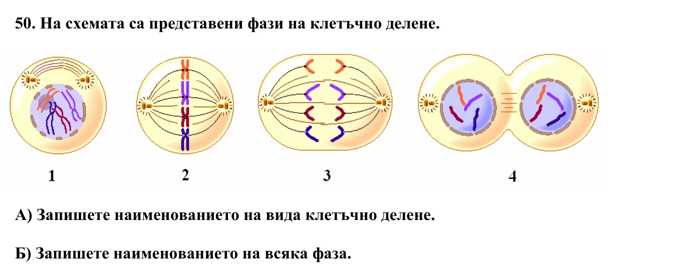


[Bulgarian | Chemistry | graph] qid=f0514ee4
  Gold: 'HIDDEN'


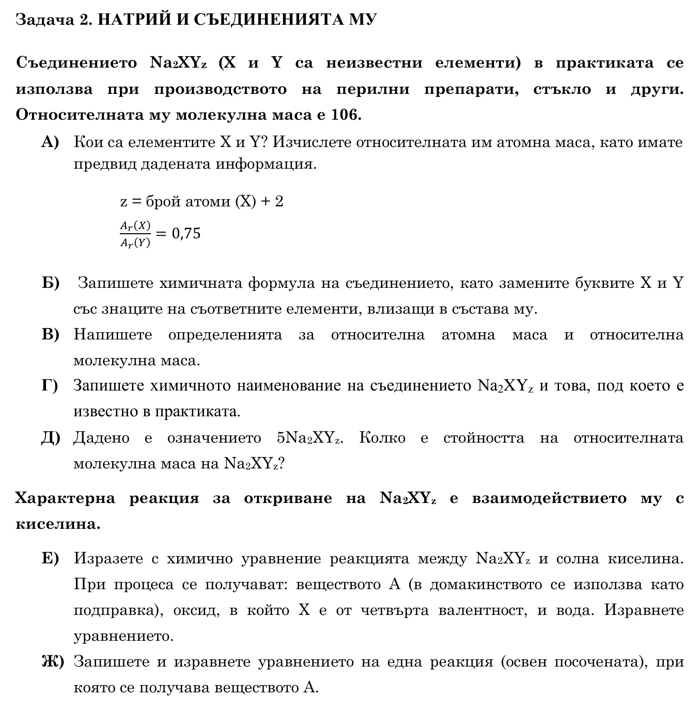


[Bulgarian | Geography | other] qid=6dc08376
  Gold: 'HIDDEN'


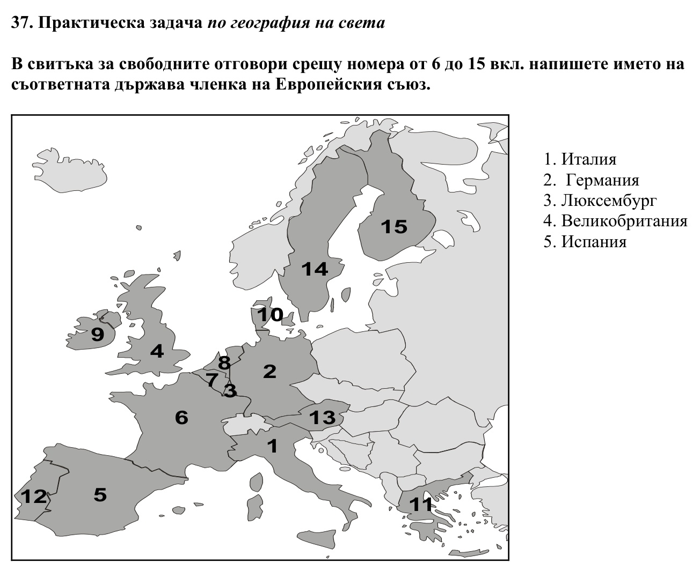


[Bulgarian | History | other] qid=9fe4e96b
  Gold: 'HIDDEN'


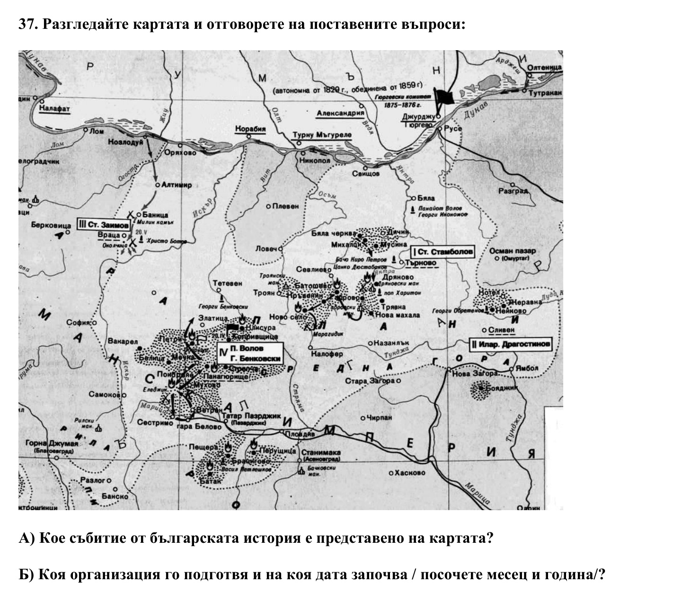


[Bulgarian | Mathematics | diagram] qid=2f1f7ab3
  Gold: 'HIDDEN'


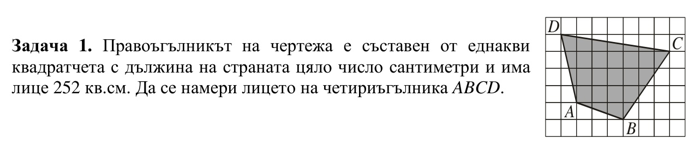


[Bulgarian | Physics | diagram] qid=4300c2a2
  Gold: 'HIDDEN'


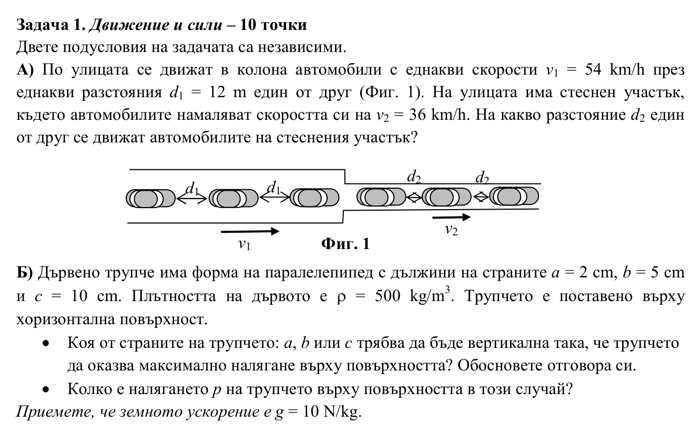


[Chinese | Biology | graph] qid=921bff3a
  Gold: 'HIDDEN'


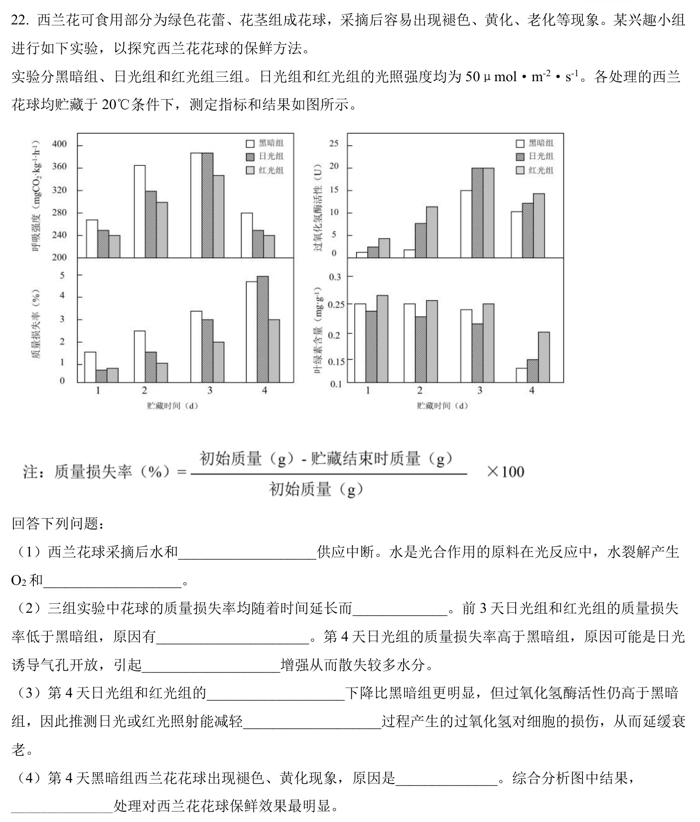


[Chinese | Chemistry | diagram] qid=e9b4d545
  Gold: 'HIDDEN'


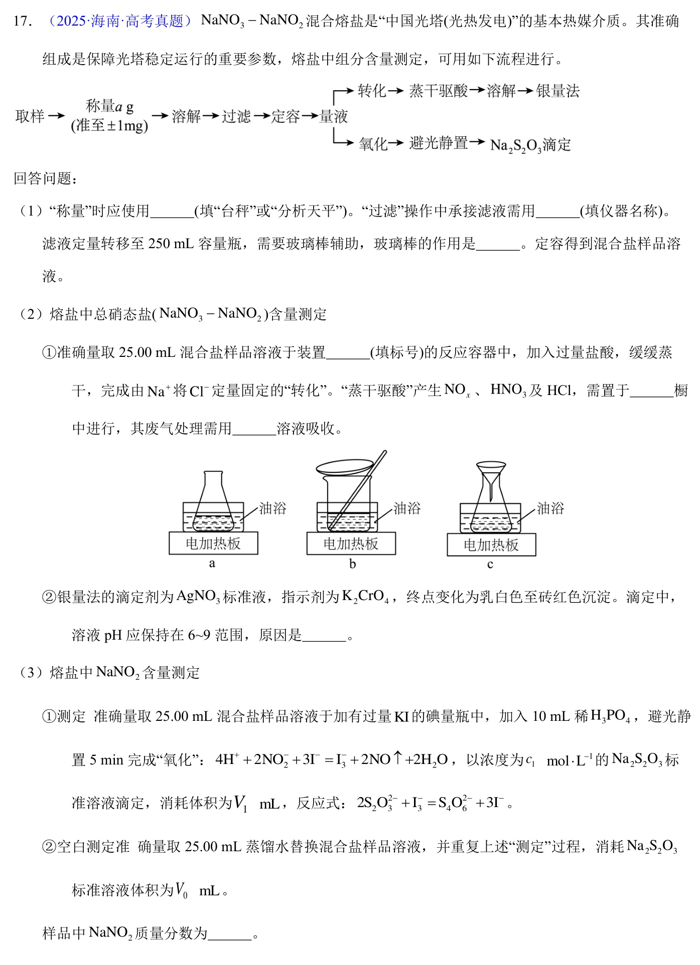


[Chinese | Mathematics | diagram] qid=b315eca0
  Gold: 'HIDDEN'


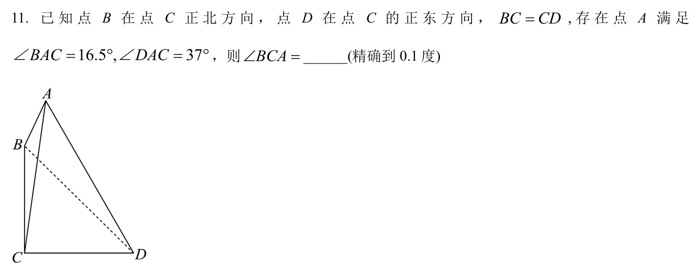


[Chinese | Physics | graph] qid=793399d0
  Gold: 'HIDDEN'


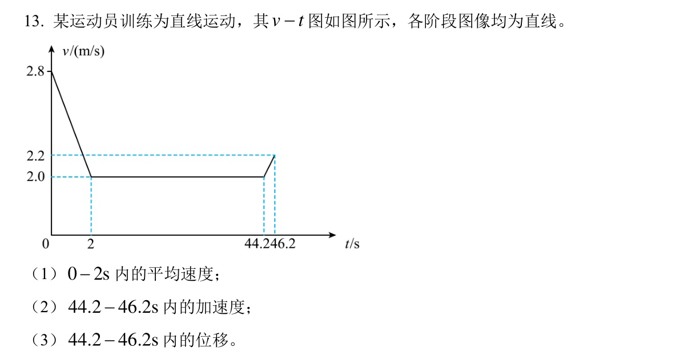


[Croatian | Biology | diagram] qid=d2a90a15
  Gold: 'HIDDEN'


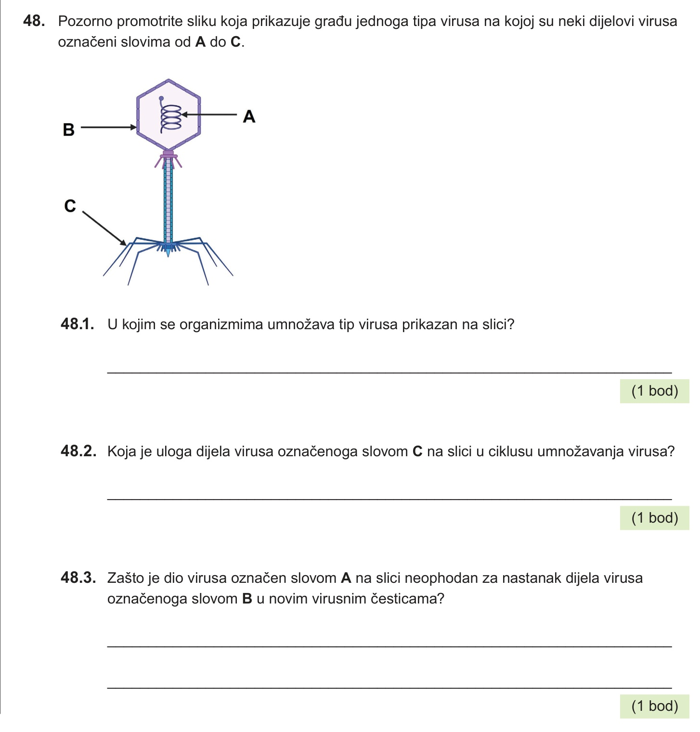


[Croatian | Chemistry | diagram] qid=2f48e4b8
  Gold: 'HIDDEN'


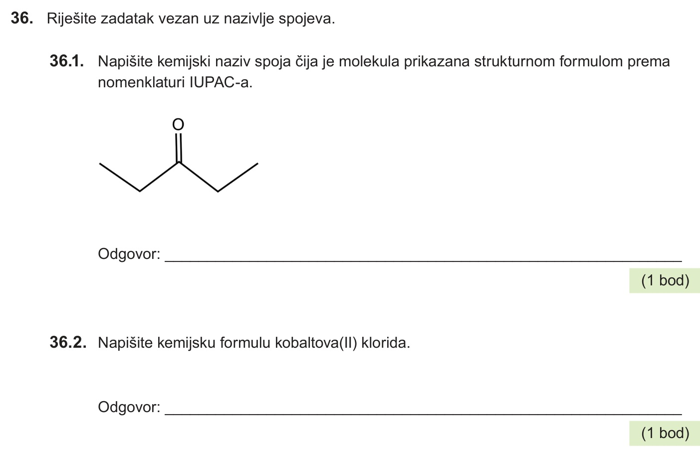


[Croatian | Geography | graph] qid=d6c592fa
  Gold: 'HIDDEN'


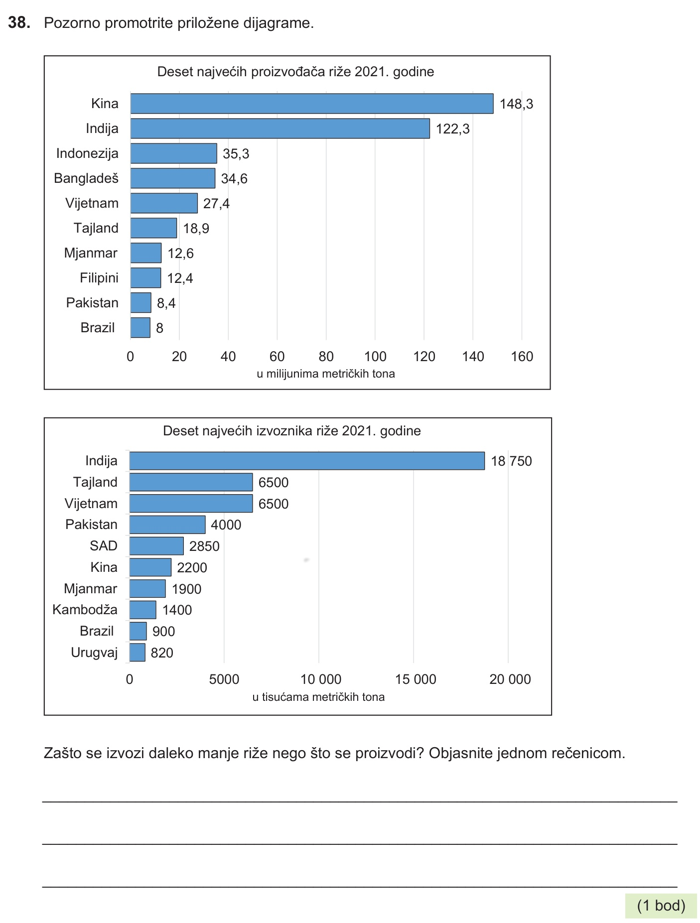


[Croatian | Mathematics | graph] qid=dad3eb5f
  Gold: 'HIDDEN'


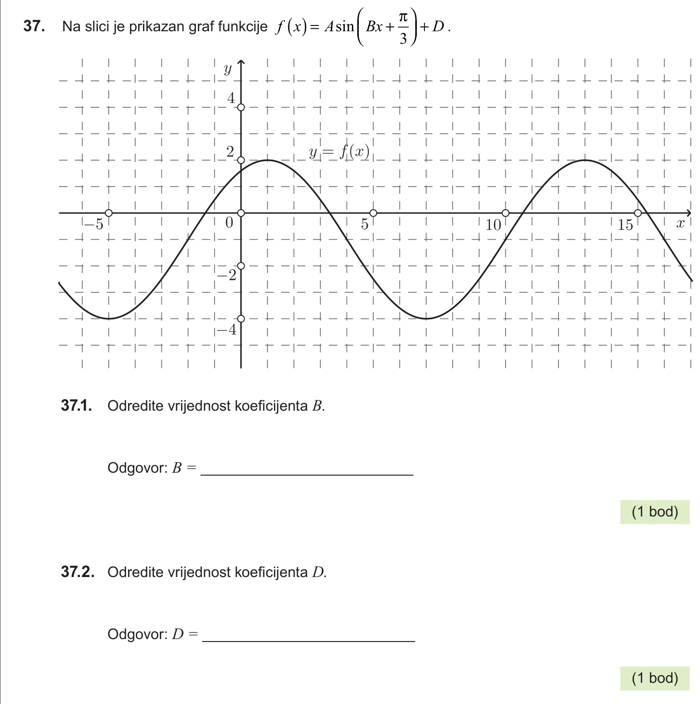


[Croatian | Physics | diagram] qid=b9dc511f
  Gold: 'HIDDEN'


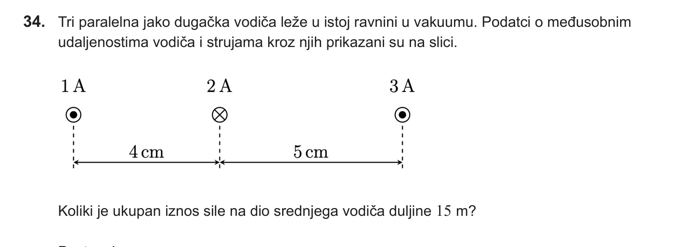


[Croatian | Psychology | diagram] qid=2a773674
  Gold: 'HIDDEN'


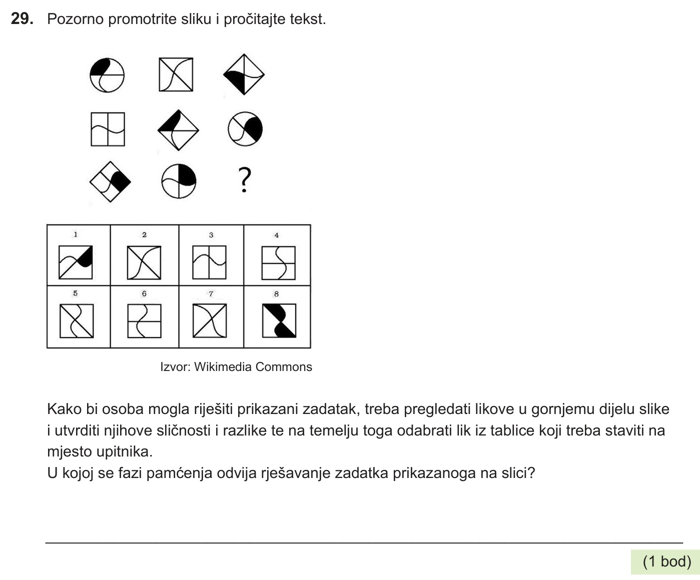


[English | Biology | table] qid=3fee2060
  Gold: 'HIDDEN'


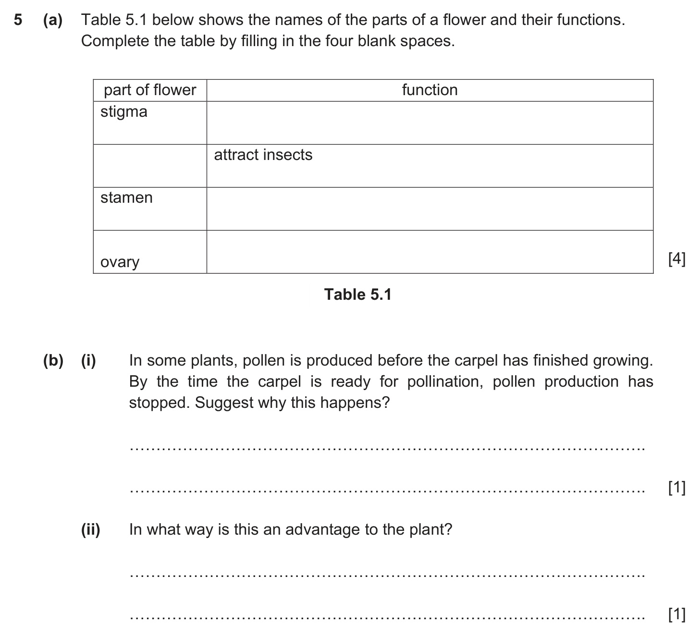


[English | Chemistry | diagram] qid=1c5e6bbb
  Gold: 'HIDDEN'


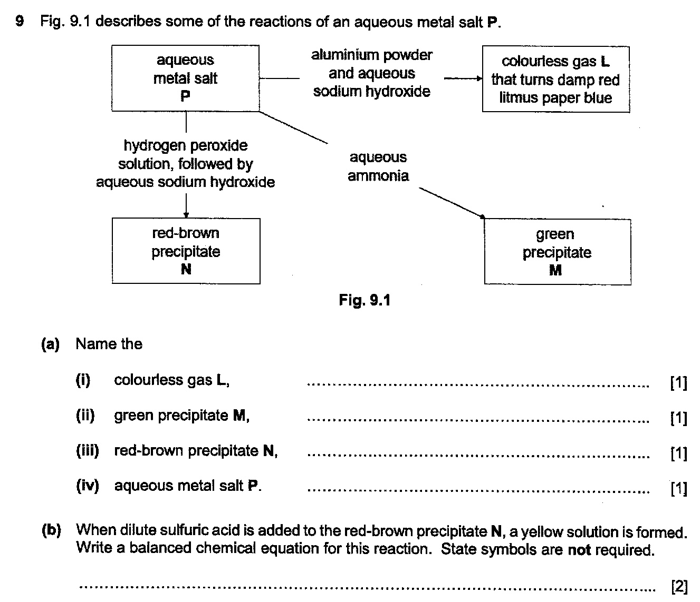


[English | Mathematics | diagram] qid=1d2f5411
  Gold: 'HIDDEN'


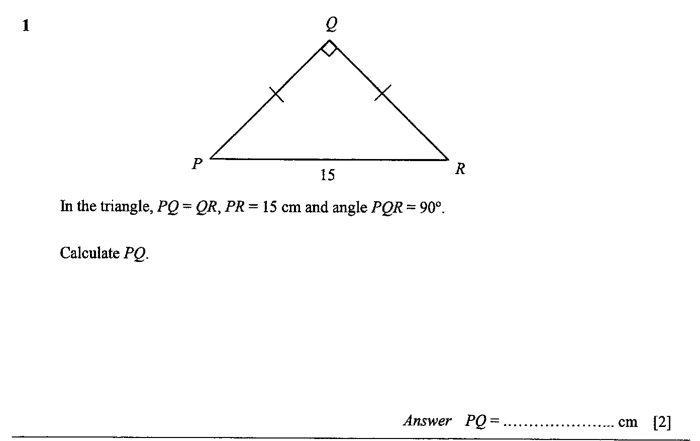


[English | Physics | diagram] qid=89b51471
  Gold: 'HIDDEN'


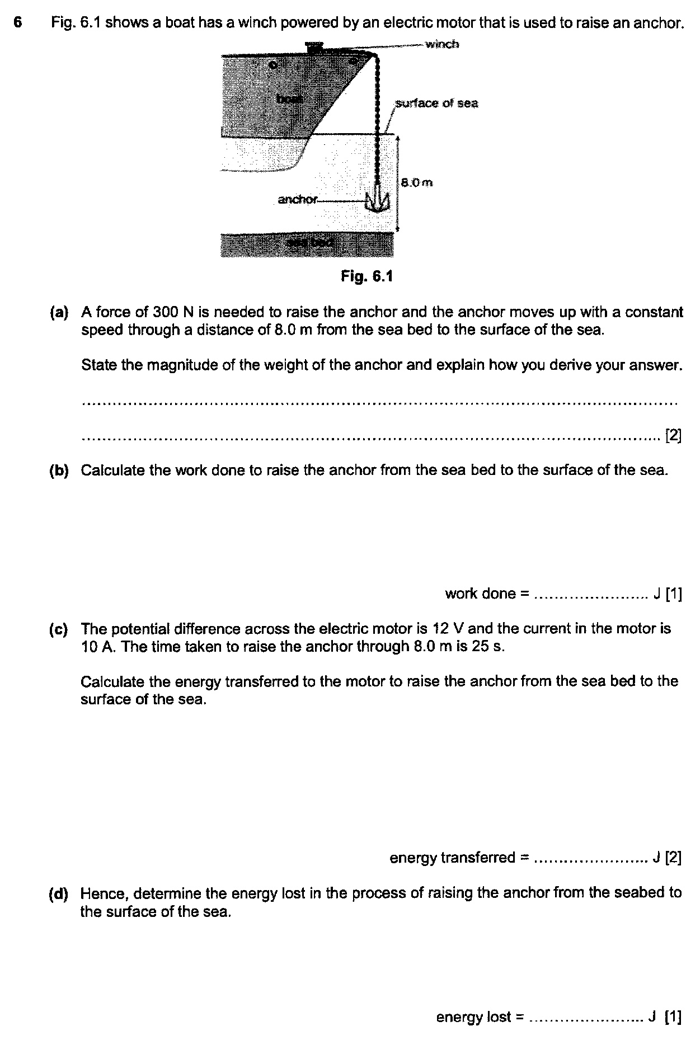


[Italian | Biology | diagram] qid=d597c88c
  Gold: 'HIDDEN'


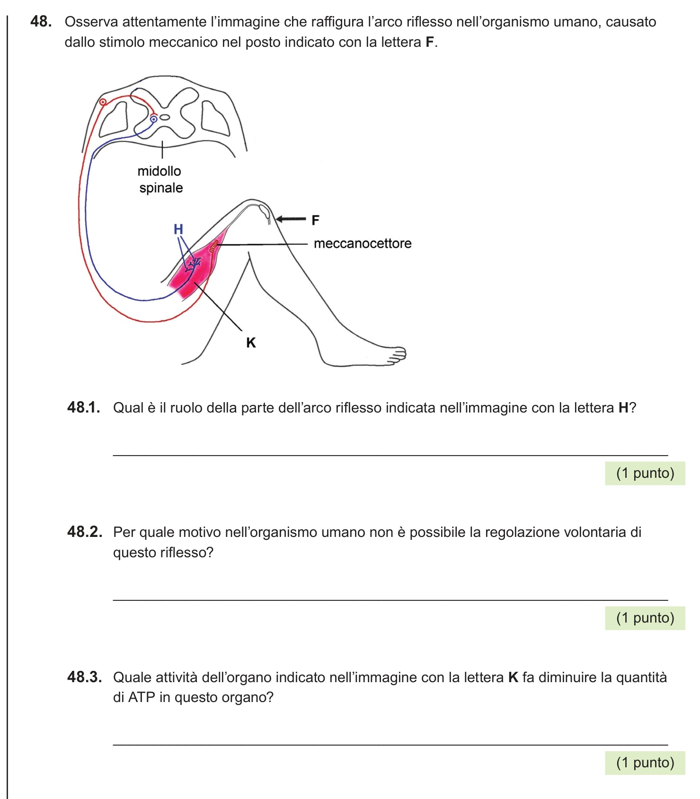


[Italian | Chemistry | diagram] qid=143e0868
  Gold: 'HIDDEN'


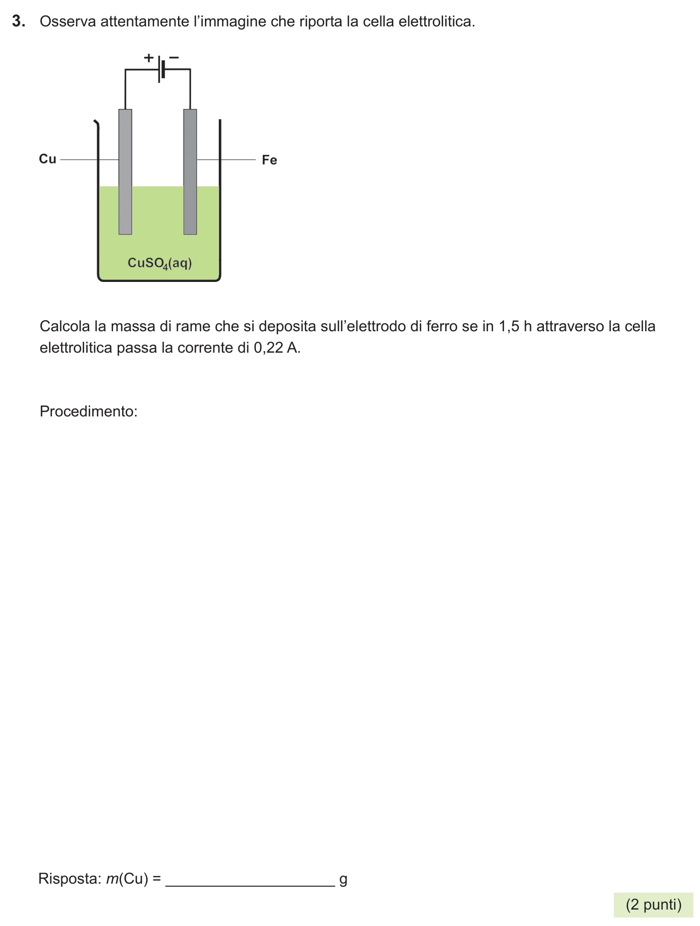


[Italian | Geography | other] qid=1f08f815
  Gold: 'HIDDEN'


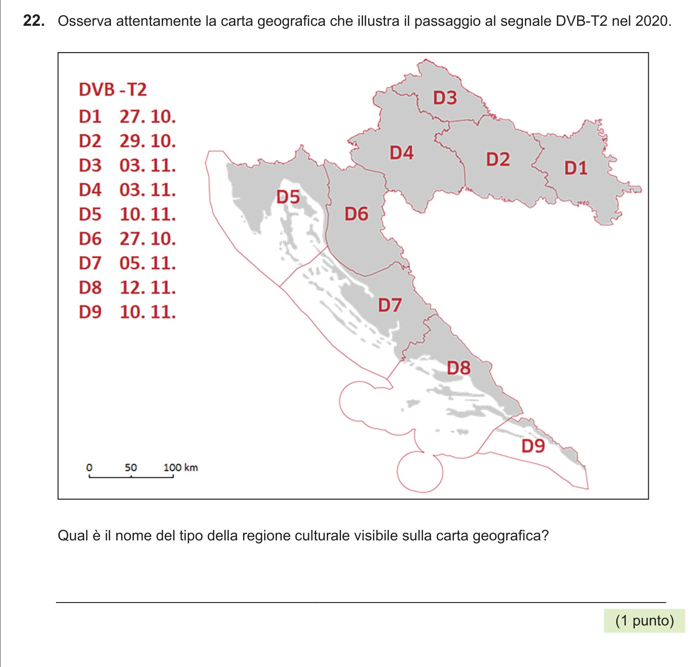


[Italian | Mathematics | graph] qid=fba7d85b
  Gold: 'HIDDEN'


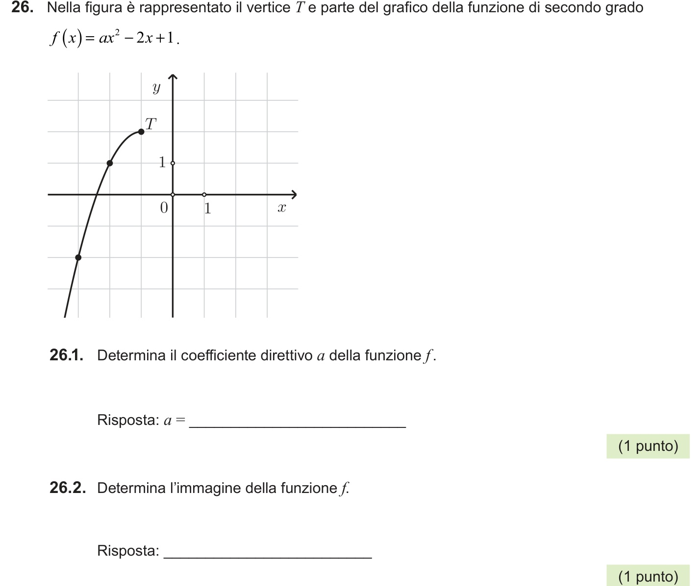


[Italian | Physics | diagram] qid=1b14a60b
  Gold: 'HIDDEN'


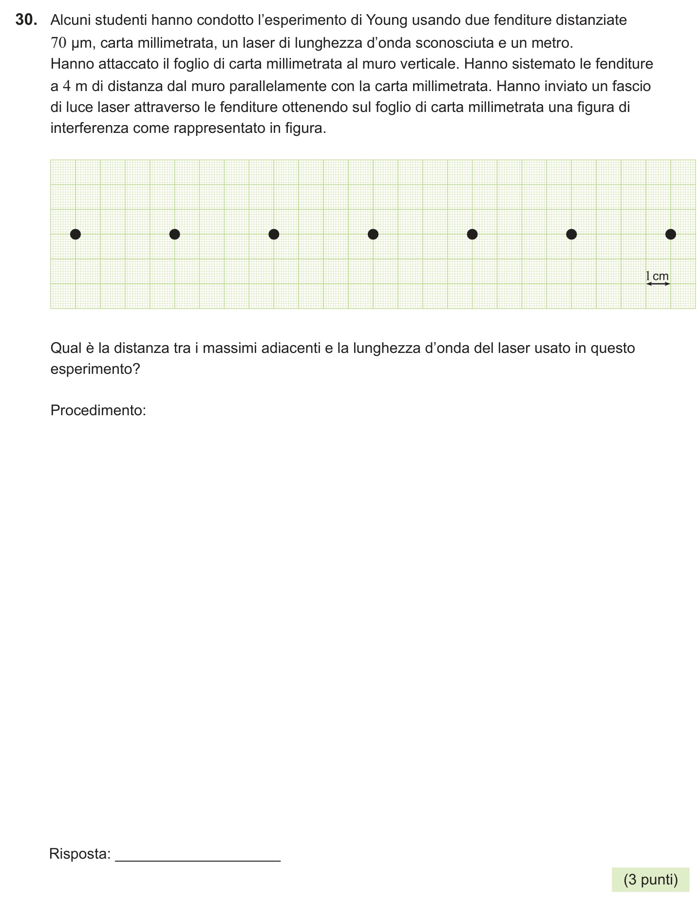


[Serbian | Biology | diagram] qid=d1c38cad
  Gold: 'HIDDEN'


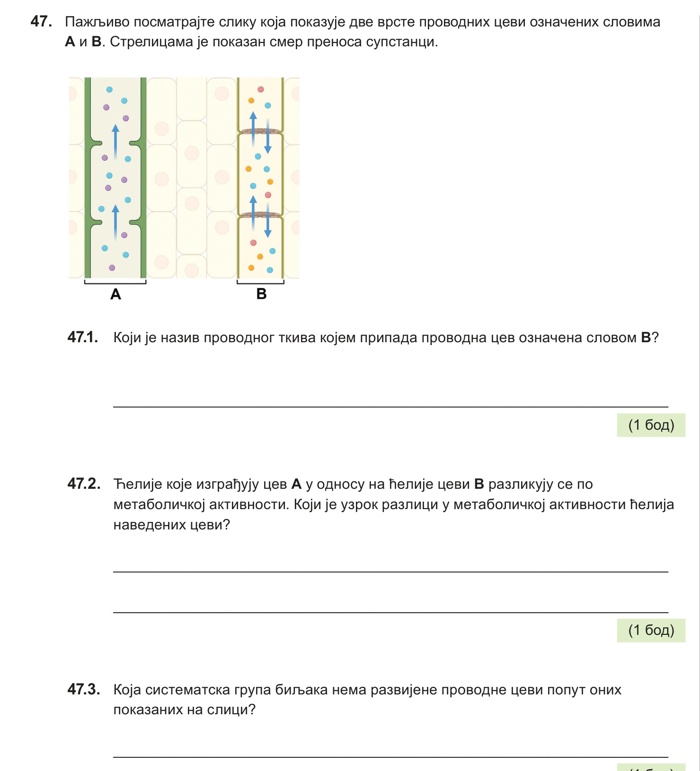


[Serbian | Chemistry | graph] qid=745edb5c
  Gold: 'HIDDEN'


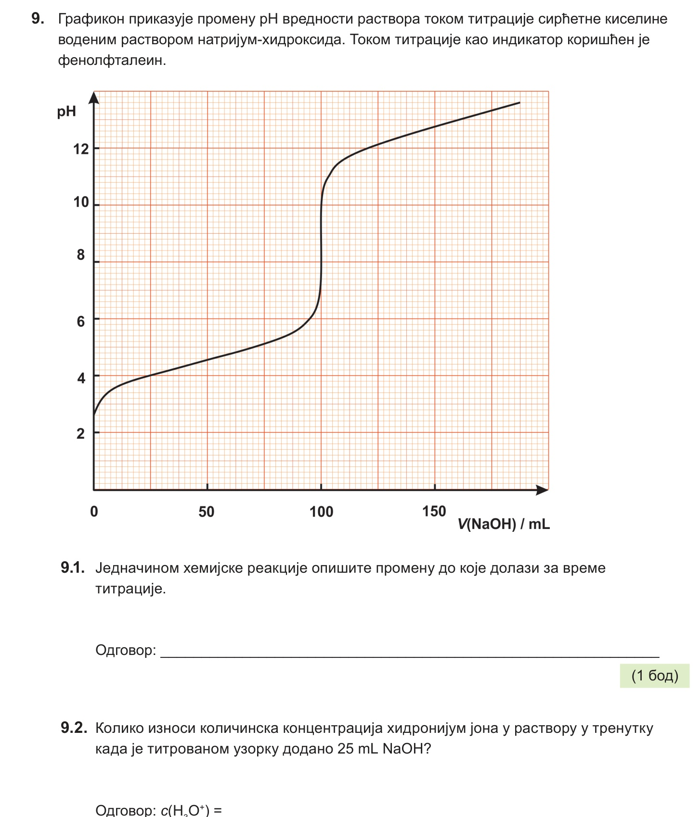


[Serbian | Geography | diagram] qid=0eae78d4
  Gold: 'HIDDEN'


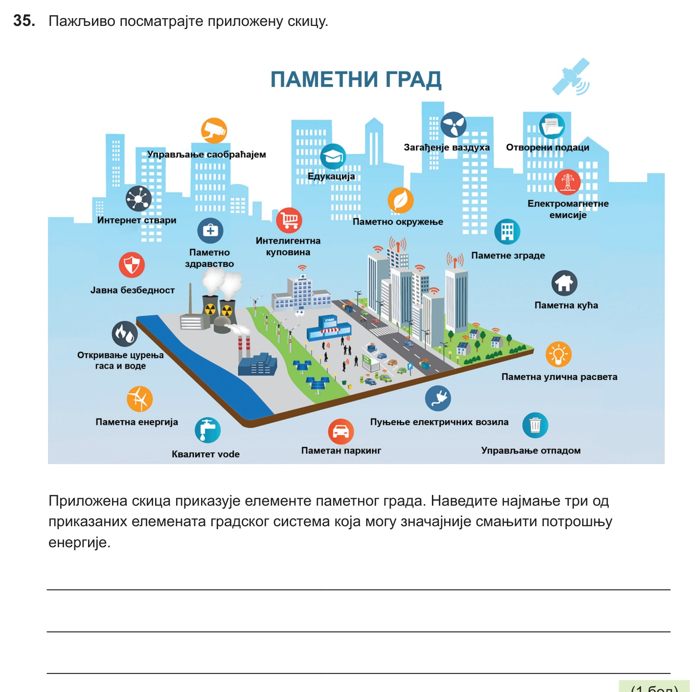


[Serbian | Mathematics | table] qid=edbd1ed6
  Gold: 'HIDDEN'


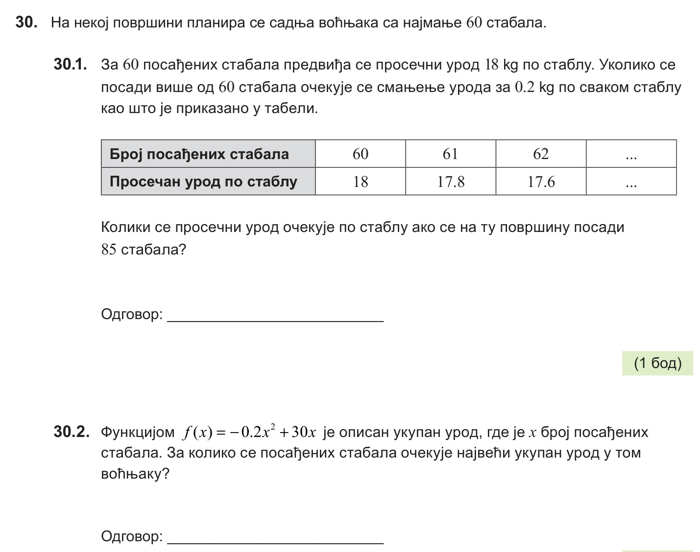


[Serbian | Physics | diagram] qid=596c5dd0
  Gold: 'HIDDEN'


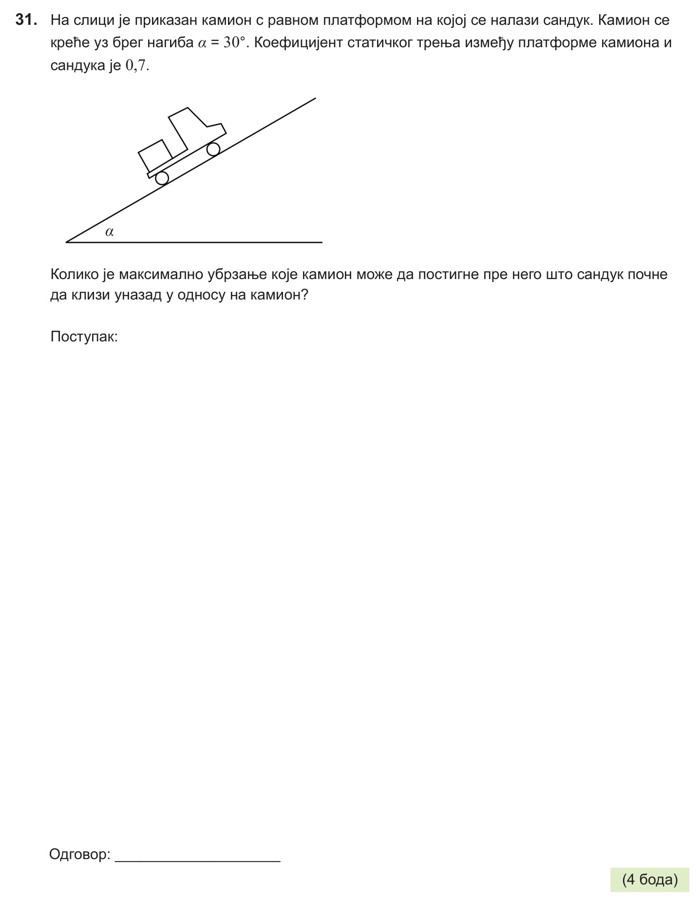

In [18]:
# 4.2 — Display sample images per (language × subject)
import random
from PIL import Image
from IPython.display import display

random.seed(42)

def show_samples(records, split, per_slice=1):
    by_slice = {}
    for r in records:
        by_slice.setdefault((r["language"], r["subject"]), []).append(r)
    print(f"--- Samples from {split} ---")
    for (lang, subj), items in sorted(by_slice.items()):
        for r in random.sample(items, min(per_slice, len(items))):
            print(f"\n[{lang} | {subj} | {graphical_type(r)}] qid={r['question_id'][:8]}")
            print(f"  Gold: {r['answer']!r}")
            try:
                img = Image.open(r["image_path"])
                w, h = img.size
                if w > 700:
                    img = img.resize((700, int(h * 700 / w)))
                display(img)
            except Exception as e:
                print(f"  (display error: {e})")

show_samples(ALL_RECORDS["dev"], "dev", per_slice=1)


## Phase 5 — Utilities

`normalize_answer` folds LaTeX, case, and trivial punctuation differences. `extract_final_answer` pulls answers out of CoT generations using `<answer>` tags, with regex and last-line fallbacks.


In [19]:
# 5.1 — Answer normalization (LaTeX, case, punctuation, option markers)
import re, unicodedata

_LATEX_REPL = [
    (r"\$", ""),
    (r"\\frac\{([^{}]+)\}\{([^{}]+)\}", r"\1/\2"),
    (r"\\cdot", "*"),
    (r"\\times", "*"),
    (r"\\degree", "°"),
    (r"\\pm", "+/-"),
    (r"\\approx", "~"),
    (r"\\(?:left|right)", ""),
    (r"_\{([^{}]+)\}", r"\1"),
    (r"\^\{([^{}]+)\}", r"\1"),
    (r"_(\w)", r"\1"),
    (r"\^(\w)", r"\1"),
    (r"\\(?:mathrm|text|mathit)\{([^{}]+)\}", r"\1"),
    (r"\\,|\\;|\\!|\\:", " "),
    (r"\\\\", " "),
]

def normalize_answer(s):
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKC", s)
    for pat, repl in _LATEX_REPL:
        s = re.sub(pat, repl, s)
    s = s.lower()
    s = re.sub(r"^[\(\[]([a-zа-яёѐ\u4e00-\u9fff0-9]{1,3})[\)\]]$", r"\1", s)
    s = s.rstrip(".,;:!?")
    s = re.sub(r"\s+", " ", s).strip()
    return s


In [20]:
# 5.2 — Final-answer extraction from CoT generations
_ANSWER_TAG_RE = re.compile(r"<answer>(.*?)</answer>", re.DOTALL | re.IGNORECASE)
_FINAL_PREFIX_RE = re.compile(
    r"(?:final answer|answer|结论|答案|odgovor|risposta|otgovor)\s*[:：]\s*(.+?)$",
    re.IGNORECASE | re.MULTILINE,
)

def extract_final_answer(text):
    if not text:
        return ""
    m = _ANSWER_TAG_RE.search(text)
    if m:
        return m.group(1).strip()
    m = _FINAL_PREFIX_RE.search(text)
    if m:
        return m.group(1).strip()
    lines = [ln.strip() for ln in text.strip().splitlines() if ln.strip()]
    return lines[-1] if lines else ""

# Sanity tests
tests = [
    ("$CO_{2}$", "co2"),
    (r"$\frac{3}{5}$", "3/5"),
    ("(б)", "б"),
    ("  CO2 . ", "co2"),
    ("0,1 nF", "0,1 nf"),
]
print("normalize_answer:")
for inp, want in tests:
    got = normalize_answer(inp)
    print(f"  [{'OK' if got == want else 'FAIL'}] {inp!r} -> {got!r} (want {want!r})")

print("\nextract_final_answer:")
for inp, want in [("blah <answer>CO2</answer>", "CO2"),
                  ("step 1\nFinal answer: 42", "42")]:
    got = extract_final_answer(inp)
    print(f"  [{'OK' if got == want else 'FAIL'}] -> {got!r}")


normalize_answer:
  [OK] '$CO_{2}$' -> 'co2' (want 'co2')
  [OK] '$\\frac{3}{5}$' -> '3/5' (want '3/5')
  [OK] '(б)' -> 'б' (want 'б')
  [OK] '  CO2 . ' -> 'co2' (want 'co2')
  [OK] '0,1 nF' -> '0,1 nf' (want '0,1 nf')

extract_final_answer:
  [OK] -> 'CO2'
  [OK] -> '42'


## Phase 6 — Multilingual prompts

Native-language instructions in all 6 dataset languages. Output constrained to `<answer>...</answer>` for reliable extraction.


In [21]:
# 6.1 — System prompts (per language)
SYSTEM_PROMPTS = {
    "English":
        "You are an expert tutor. The image shows an exam question. "
        "Read the question carefully (including any diagram, table, or graph), "
        "reason step by step, then give the shortest exact answer in English. "
        "Wrap the final answer in <answer>...</answer> tags.",
    "Bulgarian":
        "Ти си опитен учител. Изображението съдържа изпитен въпрос. "
        "Прочети въпроса внимателно (включително диаграма, таблица или графика), "
        "разсъждавай стъпка по стъпка и дай най-краткия точен отговор на български. "
        "Постави крайния отговор в <answer>...</answer>.",
    "Chinese":
        "你是一位经验丰富的老师。图片中是一道考试题目。"
        "请仔细阅读题目（包括图、表、曲线），逐步推理，"
        "然后用中文给出最简短、最准确的答案。"
        "将最终答案放在 <answer>...</answer> 标签内。",
    "Croatian":
        "Ti si iskusni nastavnik. Slika prikazuje ispitno pitanje. "
        "Pažljivo pročitaj pitanje (uključujući dijagram, tablicu ili graf), "
        "razmišljaj korak po korak i daj najkraći točan odgovor na hrvatskom. "
        "Konačni odgovor stavi u <answer>...</answer>.",
    "Italian":
        "Sei un insegnante esperto. L'immagine contiene una domanda d'esame. "
        "Leggi attentamente la domanda (compresi diagrammi, tabelle o grafici), "
        "ragiona passo passo e fornisci la risposta più breve e precisa in italiano. "
        "Racchiudi la risposta finale tra <answer>...</answer>.",
    "Serbian":
        "Ti si iskusni nastavnik. Slika prikazuje ispitno pitanje. "
        "Pažljivo pročitaj pitanje (uključujući dijagram, tabelu ili grafikon), "
        "razmišljaj korak po korak i daj najkraći tačan odgovor na srpskom. "
        "Konačan odgovor stavi u <answer>...</answer>.",
}
print("Languages:", list(SYSTEM_PROMPTS))


Languages: ['English', 'Bulgarian', 'Chinese', 'Croatian', 'Italian', 'Serbian']


In [22]:
# 6.2 — User instructions and message builder
USER_INSTRUCTIONS = {
    "English":
        "Solve the question in this image. Output your reasoning, then the "
        "final answer alone (number with units, formula, or short phrase) "
        "inside <answer>...</answer>. Do not include explanation inside the tag.",
    "Bulgarian":
        "Реши въпроса в изображението. Първо разсъжденията, след това САМО "
        "крайния отговор (число с мерна единица, формула или кратка фраза) "
        "в <answer>...</answer>. Не включвай обяснения в етикета.",
    "Chinese":
        "请解答图中的题目。先写出推理过程，然后将最终答案（数字加单位、公式"
        "或简短短语）单独放在 <answer>...</answer> 标签内。标签内不要写解释。",
    "Croatian":
        "Riješi pitanje na slici. Najprije obrazloženje, zatim SAMO konačan "
        "odgovor (broj s jedinicom, formulu ili kratku frazu) u "
        "<answer>...</answer>. Ne stavljaj objašnjenje u tag.",
    "Italian":
        "Risolvi la domanda nell'immagine. Prima il ragionamento, poi SOLO la "
        "risposta finale (numero con unità, formula o breve frase) dentro "
        "<answer>...</answer>. Non inserire spiegazioni nel tag.",
    "Serbian":
        "Reši pitanje na slici. Prvo obrazloženje, zatim SAMO konačan odgovor "
        "(broj sa jedinicom, formulu ili kratku frazu) u <answer>...</answer>. "
        "Ne stavljaj objašnjenje u tag.",
}

SUBJECT_HINTS = {
    "Biology":     "concept name, organ, process, or short phrase",
    "Chemistry":   "chemical formula or compound name",
    "Physics":     "numeric value with unit",
    "Mathematics": "numeric value or LaTeX expression",
    "Geography":   "place name or short phrase",
    "History":     "name, date, or short phrase",
}

def build_messages(image_path, language, subject_hint=None):
    sys_msg = SYSTEM_PROMPTS.get(language, SYSTEM_PROMPTS["English"])
    user = USER_INSTRUCTIONS.get(language, USER_INSTRUCTIONS["English"])
    if subject_hint:
        user = f"{user} (Expected form: {subject_hint}.)"
    return [
        {"role": "system", "content": sys_msg},
        {"role": "user", "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": user},
        ]},
    ]


## Phase 7 — Load Qwen3-VL-8B-Instruct with vLLM

First run downloads ~18 GB to `HF_CACHE` (~3-5 min on a fast connection); subsequent runs warm up in 1-2 min. Re-run **only** if you change model settings — Phases 8, 10, 11 all reuse the loaded `LLM`.

> **Image token budget.** Qwen3-VL uses 32-pixel patches (vs 28 for Qwen2.5-VL). The processor budget interface changed accordingly — we set it via `mm_processor_kwargs` below.


In [18]:
!pip install -U pip setuptools wheel packaging ninja
!pip install -U "numpy<2"

!pip install -U --prefer-binary --extra-index-url https://download.pytorch.org/whl/cu128 \
  "torch" "torchvision" "torchaudio"

!pip install -U --prefer-binary --no-cache-dir \
  "vllm>=0.11.0" "transformers>=4.57.0" "qwen-vl-utils"

Defaulting to user installation because normal site-packages is not writeable
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.1 MB/s eta 0:00:00
Using cached wheel-0.47.0-py3-none-any.whl (32 kB)
Using cached packaging-26.2-py3-none-any.whl (100 kB)
Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (180 kB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pyp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 112.4 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 112.0 MB/s  0:00:02a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 110.3 MB/s  0:00:02a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 119.2 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 109.2 MB/s  0:00:00eta 0:00:01
  Using cached cuda_pathfinder-1.5.3-py3-none-any.whl.metadata (1.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 820.3/820.3 MB 74.2 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 97.5 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 34.4 MB/s  0:00:00 eta 0:00:01
Using cached cuda_pathfinder-1.5.3-py3-none-any.whl (49 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 26.3 MB/s  0:00:00eta

  Attempting uninstall: nvidia-nccl-cu12━━━━━━━━━━━━━━━━━━━━━━━━━━  8/24 [nvidia-nvjitlink-cu12]
    Found existing installation: nvidia-nccl-cu12 2.21.5━━━━━━  8/24 [nvidia-nvjitlink-cu12]
    Uninstalling nvidia-nccl-cu12-2.21.5:m━━━━━━━━━━━━━━━━━━━━━━━━  9/24 [nvidia-nccl-cu12]]
      Successfully uninstalled nvidia-nccl-cu12-2.21.5━━━━━━━━  9/24 [nvidia-nccl-cu12]
  Attempting uninstall: nvidia-curand-cu12━━━━━━━━━━━━━━━━━━━━━━━━  9/24 [nvidia-nccl-cu12]
    Found existing installation: nvidia-curand-cu12 10.3.2.106  9/24 [nvidia-nccl-cu12]
    Uninstalling nvidia-curand-cu12-10.3.2.106:━━━━━━━━━━━━━━━  9/24 [nvidia-nccl-cu12]
      Successfully uninstalled nvidia-curand-cu12-10.3.2.106━━  9/24 [nvidia-nccl-cu12]
  Attempting uninstall: nvidia-cuda-runtime-cu12━━━━━━━━━━━━━━━━━━ 10/24 [nvidia-curand-cu12]
    Found existing installation: nvidia-cuda-runtime-cu12 12.1.105 10/24 [nvidia-curand-cu12]
    Uninstalling nvidia-cuda-runtime-cu12-12.1.105:━━━━━━━━━━━ 10/24 [nvidia-curand-c

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.3/370.3 MB 47.6 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 34.0 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 33.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 41.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 53.0 MB/s  0:00:21m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 43.8 MB/s  0:00:17m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 37.0 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 41.4 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.8 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 59.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 49.1 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 41.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 50.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 61.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 69.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 85.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 79.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 71.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 59.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 MB 63.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

  Attempting uninstall: ray━━━━━━━━━━━━━╸━━━━━━━ 37/45 [torchaudio]
    Found existing installation: ray 2.40.01m╸━━━━━━━ 37/45 [torchaudio]
    Uninstalling ray-2.40.0:━━━━━━━━━━━━━╸━━━━━━ 38/45 [ray]io]
      Successfully uninstalled ray-2.40.0╸━━━━━━ 38/45 [ray]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━ 38/45 [ray]  WARNING: The scripts ray, serve and tune are installed in '/home/pmp6991/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 40/45 [model-hosting-container-standards]  WARNING: The scripts generate-supervisor-config and standard-supervisor are installed in '/home/pmp6991/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Attempting uninstall: xgrammar
    Found existing installation: xgrammar 0.1.11m━━━ 40/45 [model-hosting-container-s

In [1]:
import vllm
print(vllm.__version__)

0.11.2


In [8]:
# 7.1 — Load Qwen3-VL-8B-Instruct (BF16) — heavy cell
from vllm import LLM, SamplingParams

MODEL_NAME = "Qwen/Qwen3-VL-8B-Instruct"

llm = LLM(
    model=MODEL_NAME,
    tensor_parallel_size=TENSOR_PARALLEL_SIZE,
    dtype="bfloat16",
    gpu_memory_utilization=0.85,        # 8B leaves room for KV cache
    max_model_len=16384,                # exam pages can be long
    trust_remote_code=True,
    limit_mm_per_prompt={"image": 1},
    mm_processor_kwargs={
        # Qwen3-VL: image_processor.size uses longest_edge / shortest_edge
        # in pixel-equivalent terms (32x32 patches, 4× spatial compression).
        # Range 256-1280 visual tokens is a good speed/quality tradeoff.
        "min_pixels": 256 * 32 * 32,    # 262,144
        "max_pixels": 1280 * 32 * 32,   # 1,310,720
    },
)
print("Model loaded.")


/miniconda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 04-25 15:12:30 [utils.py:253] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'max_model_len': 16384, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'limit_mm_per_prompt': {'image': 1}, 'mm_processor_kwargs': {'min_pixels': 262144, 'max_pixels': 1310720}, 'model': 'Qwen/Qwen3-VL-8B-Instruct'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 04-25 15:13:03 [model.py:631] Resolved architecture: Qwen3VLForConditionalGeneration
INFO 04-25 15:13:03 [model.py:1745] Using max model len 16384


2026-04-25 15:13:06,237	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


...

(EngineCore_DP0 pid=3895618) INFO 04-25 15:15:56 [default_loader.py:314] Loading weights took 19.05 seconds
(EngineCore_DP0 pid=3895618) INFO 04-25 15:15:56 [gpu_model_runner.py:3338] Model loading took 16.7803 GiB memory and 156.206404 seconds
(EngineCore_DP0 pid=3895618) INFO 04-25 15:15:57 [gpu_model_runner.py:4088] Encoder cache will be initialized with a budget of 153600 tokens, and profiled with 1 video items of the maximum feature size.
(EngineCore_DP0 pid=3895618) INFO 04-25 15:16:30 [backends.py:631] Using cache directory: /tmp/pmp6991-jupyter//xdg_cache_home/vllm/torch_compile_cache/06955627fe/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=3895618) INFO 04-25 15:16:30 [backends.py:647] Dynamo bytecode transform time: 22.49 s


(EngineCore_DP0 pid=3895618) [rank0]:W0425 15:16:33.688000 3895618 torch/_inductor/codegen/triton_combo_kernel.py:97] [0/0] ComboKernels: 1 long reduction nodes are separated
(EngineCore_DP0 pid=3895618) [rank0]:W0425 15:16:39.459000 3895618 torch/_inductor/codegen/triton_combo_kernel.py:97] [0/0] ComboKernels: 1 long reduction nodes are separated


(EngineCore_DP0 pid=3895618) INFO 04-25 15:16:42 [backends.py:251] Cache the graph for dynamic shape for later use
(EngineCore_DP0 pid=3895618) INFO 04-25 15:17:17 [backends.py:282] Compiling a graph for dynamic shape takes 46.72 s
(EngineCore_DP0 pid=3895618) INFO 04-25 15:17:19 [monitor.py:34] torch.compile takes 69.22 s in total
(EngineCore_DP0 pid=3895618) INFO 04-25 15:17:21 [gpu_worker.py:359] Available KV cache memory: 10.10 GiB
(EngineCore_DP0 pid=3895618) INFO 04-25 15:17:21 [kv_cache_utils.py:1229] GPU KV cache size: 73,504 tokens
(EngineCore_DP0 pid=3895618) INFO 04-25 15:17:21 [kv_cache_utils.py:1234] Maximum concurrency for 16,384 tokens per request: 4.49x


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:02<00:00, 20.86it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 21.38it/s]


(EngineCore_DP0 pid=3895618) INFO 04-25 15:17:26 [gpu_model_runner.py:4244] Graph capturing finished in 5 secs, took 0.69 GiB
(EngineCore_DP0 pid=3895618) INFO 04-25 15:17:26 [core.py:250] init engine (profile, create kv cache, warmup model) took 89.81 seconds
INFO 04-25 15:17:28 [llm.py:352] Supported tasks: ['generate']
Model loaded.


## Phase 8 — Inference: zero-shot CoT baseline

For Qwen3-VL the model card recommends **sampling** rather than greedy decoding:

```
temperature=0.7, top_p=0.8, top_k=20, presence_penalty=1.5
```

We use these as the baseline (single sample, n=1) — they tend to outperform pure greedy on this model.


In [24]:
# 8.1 — Helper: run vLLM chat over a list of records
import base64
from io import BytesIO
from PIL import Image
from tqdm.auto import tqdm

def _pil_to_data_url(img: Image.Image) -> str:
    buf = BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode()
    return f"data:image/png;base64,{b64}"

def messages_with_pil(records, *, subject_hint_map=None):
    """Build chat messages with images encoded as base64 data URLs (image_url format)."""
    chats = []
    for r in records:
        hint = None
        if subject_hint_map:
            hint = subject_hint_map.get(r.get("subject"))
        msgs = build_messages(r["image_path"], r["language"], subject_hint=hint)
        new_msgs = []
        for m in msgs:
            if isinstance(m["content"], list):
                content = []
                for blk in m["content"]:
                    if blk.get("type") == "image":
                        img = Image.open(blk["image"]).convert("RGB")
                        content.append({
                            "type": "image_url",
                            "image_url": {"url": _pil_to_data_url(img)},
                        })
                    else:
                        content.append(blk)
                new_msgs.append({"role": m["role"], "content": content})
            else:
                new_msgs.append(m)
        chats.append(new_msgs)
    return chats

def run_inference(records, sampling_params, *, subject_hint_map=None,
                  desc="inference"):
    chats = messages_with_pil(records, subject_hint_map=subject_hint_map)
    print(f"  {len(chats)} prompts | n={sampling_params.n} | "
          f"T={sampling_params.temperature}")
    outs = llm.chat(messages=chats, sampling_params=sampling_params,
                    use_tqdm=True)
    return [[o.text for o in out.outputs] for out in outs]

In [25]:
# 8.2 — Run zero-shot CoT on dev (Qwen3-VL recommended sampling)
dev_records = ALL_RECORDS["dev"]

baseline_params = SamplingParams(
    n=1,
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    presence_penalty=1.5,
    max_tokens=1024,
)

raw_dev_cot = run_inference(dev_records, baseline_params, desc="dev/cot")

dev_cot_predictions = []
dev_cot_raw_dump = []
for rec, gens in zip(dev_records, raw_dev_cot):
    final = extract_final_answer(gens[0]) if gens else ""
    dev_cot_predictions.append({
        "question_id": rec["question_id"],
        "answers": [final],
        "language": rec["language"],
    })
    dev_cot_raw_dump.append({
        "question_id": rec["question_id"],
        "language": rec["language"],
        "subject": rec["subject"],
        "gold": rec["answer"],
        "generation": gens[0] if gens else "",
        "extracted": final,
    })

import json
with open(OUTPUTS / "dev_cot_predictions.json", "w", encoding="utf-8") as f:
    json.dump(dev_cot_predictions, f, ensure_ascii=False, indent=2)
with open(OUTPUTS / "dev_cot_raw.json", "w", encoding="utf-8") as f:
    json.dump(dev_cot_raw_dump, f, ensure_ascii=False, indent=2)

print(f"\nDone. {len(dev_cot_predictions)} predictions saved.")
print("\nFirst 3 examples:")
for r, p in zip(dev_records[:3], dev_cot_predictions[:3]):
    print(f"  qid={r['question_id'][:8]} [{r['language']}/{r['subject']}]")
    print(f"    gold : {r['answer']!r}")
    print(f"    pred : {p['answers'][0]!r}")


  240 prompts | n=1 | T=0.7


Processed prompts: 100%|██████████| 240/240 [02:13<00:00,  1.80it/s, est. speed input: 2339.64 toks/s, output: 1233.08 toks/s]


Done. 240 predictions saved.

First 3 examples:
  qid=6dc08376 [Bulgarian/Geography]
    gold : 'HIDDEN'
    pred : 'Но ако приемем, че въпросът е да се из'
  qid=2b8a6961 [Bulgarian/Physics]
    gold : 'HIDDEN'
    pred : '1.25 мин'
  qid=ecb0f858 [Bulgarian/History]
    gold : 'HIDDEN'
    pred : '9 ноември 1989 г.'


## Phase 9 — Evaluation: multi-metric, per-slice

Reports EM, normalized EM, token-F1, and contains. All four are shown overall and per language / subject / graphical type.


In [26]:
# 9.1 — Metric primitives
from collections import defaultdict

_TOKEN_RE = re.compile(r"\w+", re.UNICODE)
_tokens = lambda s: _TOKEN_RE.findall(normalize_answer(s))

def em(pred, gold):       return float(pred.strip() == gold.strip())
def norm_em(pred, gold):  return float(normalize_answer(pred) == normalize_answer(gold))

def contains(pred, gold):
    p, g = normalize_answer(pred), normalize_answer(gold)
    if not g: return 0.0
    return float(g in p or p in g)

def token_f1(pred, gold):
    p_t, g_t = _tokens(pred), _tokens(gold)
    if not p_t and not g_t: return 1.0
    if not p_t or not g_t: return 0.0
    overlap = sum(min(p_t.count(t), g_t.count(t)) for t in set(p_t) & set(g_t))
    if overlap == 0: return 0.0
    p, r = overlap / len(p_t), overlap / len(g_t)
    return 2 * p * r / (p + r)


In [27]:
# 9.2 — Per-slice reporting
def report_metric(name, scores, records):
    overall = sum(scores) / len(scores) if scores else 0.0
    print(f"\n=== {name} ===  overall: {overall*100:.2f}")

    def by(field, fn):
        groups = defaultdict(list)
        for i, r in enumerate(records):
            groups[fn(r)].append(i)
        print(f"  by {field}:")
        for k in sorted(groups):
            sel = [scores[i] for i in groups[k]]
            v = (sum(sel) / len(sel)) * 100 if sel else 0
            print(f"    {k:<14} {v:>6.2f}  (n={len(sel)})")

    by("language",   lambda r: r["language"])
    by("subject",    lambda r: r["subject"])
    by("graph type", graphical_type)

def evaluate(predictions, gold_records, label):
    pred_by_id = {p["question_id"]: p for p in predictions}
    aligned = [(r, (pred_by_id.get(r["question_id"], {}).get("answers") or [""])[0],
                r["answer"] or "")
               for r in gold_records if r["question_id"] in pred_by_id]
    recs  = [a[0] for a in aligned]
    preds = [a[1] for a in aligned]
    golds = [a[2] for a in aligned]

    print(f"\n{'#'*60}")
    print(f"# {label}  (n={len(recs)})")
    print('#'*60)
    em_s   = [em(p, g)       for p, g in zip(preds, golds)]
    nem_s  = [norm_em(p, g)  for p, g in zip(preds, golds)]
    f1_s   = [token_f1(p, g) for p, g in zip(preds, golds)]
    cont_s = [contains(p, g) for p, g in zip(preds, golds)]

    report_metric("EM",       em_s,   recs)
    report_metric("norm-EM",  nem_s,  recs)
    report_metric("token-F1", f1_s,   recs)
    report_metric("contains", cont_s, recs)

    return {
        "n": len(recs),
        "EM":       sum(em_s)/len(em_s),
        "norm_EM":  sum(nem_s)/len(nem_s),
        "token_F1": sum(f1_s)/len(f1_s),
        "contains": sum(cont_s)/len(cont_s),
    }

baseline_summary = evaluate(dev_cot_predictions, dev_records, "Zero-shot CoT (baseline)")
print("\nSummary:", baseline_summary)



############################################################
# Zero-shot CoT (baseline)  (n=240)
############################################################

=== EM ===  overall: 0.00
  by language:
    Bulgarian        0.00  (n=50)
    Chinese          0.00  (n=50)
    Croatian         0.00  (n=50)
    English          0.00  (n=50)
    Italian          0.00  (n=20)
    Serbian          0.00  (n=20)
  by subject:
    Biology          0.00  (n=40)
    Chemistry        0.00  (n=37)
    Geography        0.00  (n=38)
    History          0.00  (n=3)
    Mathematics      0.00  (n=54)
    Physics          0.00  (n=67)
    Psychology       0.00  (n=1)
  by graph type:
    diagram          0.00  (n=149)
    graph            0.00  (n=34)
    other            0.00  (n=30)
    table            0.00  (n=27)

=== norm-EM ===  overall: 0.00
  by language:
    Bulgarian        0.00  (n=50)
    Chinese          0.00  (n=50)
    Croatian         0.00  (n=50)
    English          0.00  (n=50)
    Ital

In [28]:
# 9.3 — (Optional) Multilingual BERTScore. Slow first run.
def bertscore_eval(predictions, gold_records):
    from bert_score import score as bs_score
    pred_by_id = {p["question_id"]: p for p in predictions}
    by_lang = defaultdict(list)
    for r in gold_records:
        if r["question_id"] in pred_by_id:
            pred = (pred_by_id[r["question_id"]].get("answers") or [""])[0] or " "
            gold = r["answer"] or " "
            by_lang[r["language"]].append((r, pred, gold))

    bs_lang_map = {"English": "en", "Chinese": "zh", "Bulgarian": "bg",
                   "Croatian": "hr", "Italian": "it", "Serbian": "sr"}
    all_scores, all_recs = [], []
    for lang, items in by_lang.items():
        recs, ps, gs = zip(*items)
        _, _, F1 = bs_score(list(ps), list(gs),
                            lang=bs_lang_map.get(lang, "en"),
                            rescale_with_baseline=False, verbose=False)
        for r, f in zip(recs, F1.tolist()):
            all_recs.append(r); all_scores.append(float(f))
    report_metric("BERTScore-F1", all_scores, all_recs)
    return sum(all_scores) / len(all_scores)

# bertscore_eval(dev_cot_predictions, dev_records)
print("Uncomment the call above to compute BERTScore.")


Uncomment the call above to compute BERTScore.


## Phase 10 — Self-consistency

Sample 5 chains, vote on the normalized final answer. Typically a 2–5 point gain on multi-step questions, especially math/physics. **Particularly useful with the smaller 8B model**, since each individual chain is noisier than the 72B's.


In [29]:
# 10.1 — Self-consistency (n=5)
from collections import Counter

consist_params = SamplingParams(
    n=5,
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    presence_penalty=1.5,
    max_tokens=1024,
)

raw_dev_consist = run_inference(dev_records, consist_params, desc="dev/consist")

def vote(answers):
    if not answers:
        return ""
    counts = Counter(normalize_answer(a) for a in answers)
    top_norm, _ = counts.most_common(1)[0]
    for a in answers:
        if normalize_answer(a) == top_norm:
            return a
    return answers[0]

dev_consist_predictions = []
dev_consist_raw_dump = []
for rec, gens in zip(dev_records, raw_dev_consist):
    finals = [extract_final_answer(g) for g in gens]
    chosen = vote(finals)
    dev_consist_predictions.append({
        "question_id": rec["question_id"],
        "answers": [chosen],
        "language": rec["language"],
    })
    dev_consist_raw_dump.append({
        "question_id": rec["question_id"],
        "language": rec["language"],
        "subject": rec["subject"],
        "gold": rec["answer"],
        "generations": gens,
        "extracted": finals,
        "voted": chosen,
    })

with open(OUTPUTS / "dev_consist_predictions.json", "w", encoding="utf-8") as f:
    json.dump(dev_consist_predictions, f, ensure_ascii=False, indent=2)
with open(OUTPUTS / "dev_consist_raw.json", "w", encoding="utf-8") as f:
    json.dump(dev_consist_raw_dump, f, ensure_ascii=False, indent=2)

consist_summary = evaluate(dev_consist_predictions, dev_records,
                           "Self-consistency (n=5)")


  240 prompts | n=5 | T=0.7


Processed prompts: 100%|██████████| 1200/1200 [07:13<00:00,  2.77it/s, est. speed input: 3601.24 toks/s, output: 1938.08 toks/s]


############################################################
# Self-consistency (n=5)  (n=240)
############################################################

=== EM ===  overall: 0.00
  by language:
    Bulgarian        0.00  (n=50)
    Chinese          0.00  (n=50)
    Croatian         0.00  (n=50)
    English          0.00  (n=50)
    Italian          0.00  (n=20)
    Serbian          0.00  (n=20)
  by subject:
    Biology          0.00  (n=40)
    Chemistry        0.00  (n=37)
    Geography        0.00  (n=38)
    History          0.00  (n=3)
    Mathematics      0.00  (n=54)
    Physics          0.00  (n=67)
    Psychology       0.00  (n=1)
  by graph type:
    diagram          0.00  (n=149)
    graph            0.00  (n=34)
    other            0.00  (n=30)
    table            0.00  (n=27)

=== norm-EM ===  overall: 0.00
  by language:
    Bulgarian        0.00  (n=50)
    Chinese          0.00  (n=50)
    Croatian         0.00  (n=50)
    English          0.00  (n=50)
    Italia

## Phase 11 — Subject-specialized prompts

Append a one-line hint about the expected answer form. Cheap to add, often nudges the model toward canonical gold formatting.


In [30]:
# 11.1 — Subject-hint inference (uses baseline_params, n=1)
raw_dev_subj = run_inference(dev_records, baseline_params,
                             subject_hint_map=SUBJECT_HINTS,
                             desc="dev/subject-hint")

dev_subj_predictions = []
for rec, gens in zip(dev_records, raw_dev_subj):
    final = extract_final_answer(gens[0]) if gens else ""
    dev_subj_predictions.append({
        "question_id": rec["question_id"],
        "answers": [final],
        "language": rec["language"],
    })

with open(OUTPUTS / "dev_subjhint_predictions.json", "w", encoding="utf-8") as f:
    json.dump(dev_subj_predictions, f, ensure_ascii=False, indent=2)

subj_summary = evaluate(dev_subj_predictions, dev_records,
                        "CoT + subject hints")


  240 prompts | n=1 | T=0.7


Processed prompts: 100%|██████████| 240/240 [02:34<00:00,  1.55it/s, est. speed input: 2034.85 toks/s, output: 1050.84 toks/s]


############################################################
# CoT + subject hints  (n=240)
############################################################

=== EM ===  overall: 0.00
  by language:
    Bulgarian        0.00  (n=50)
    Chinese          0.00  (n=50)
    Croatian         0.00  (n=50)
    English          0.00  (n=50)
    Italian          0.00  (n=20)
    Serbian          0.00  (n=20)
  by subject:
    Biology          0.00  (n=40)
    Chemistry        0.00  (n=37)
    Geography        0.00  (n=38)
    History          0.00  (n=3)
    Mathematics      0.00  (n=54)
    Physics          0.00  (n=67)
    Psychology       0.00  (n=1)
  by graph type:
    diagram          0.00  (n=149)
    graph            0.00  (n=34)
    other            0.00  (n=30)
    table            0.00  (n=27)

=== norm-EM ===  overall: 0.00
  by language:
    Bulgarian        0.00  (n=50)
    Chinese          0.00  (n=50)
    Croatian         0.00  (n=50)
    English          0.00  (n=50)
    Italian  

In [31]:
# 11.2 — Compare strategies side by side
import pandas as pd
comparison = pd.DataFrame({
    "Zero-shot CoT":          baseline_summary,
    "Self-consistency (n=5)": consist_summary,
    "CoT + subject hints":    subj_summary,
}).T[["EM", "norm_EM", "token_F1", "contains"]] * 100

print("Dev results (%):")
print(comparison.round(2).to_string())


Dev results (%):
                         EM  norm_EM  token_F1  contains
Zero-shot CoT           0.0      0.0       0.0      0.83
Self-consistency (n=5)  0.0      0.0       0.0      0.83
CoT + subject hints     0.0      0.0       0.0      0.83


## Phase 12 — Build final submission

Once test is released, run inference on test with your best dev strategy and produce the AI4Media-Bench JSON.

Format checklist:
- list of `{question_id, answers (list[str]), language}`
- size matches test set size
- no duplicate IDs
- entries with no answer get `answers: [""]`
- valid JSON


In [34]:
# 12.1 — Run on test (after downloading test split in Phase 3)
TEST_AVAILABLE = "test" in ALL_RECORDS

if TEST_AVAILABLE:
    test_records = ALL_RECORDS["test"]
    # Switch to whichever strategy won on dev. Defaulting to self-consistency.
    raw_test = run_inference(test_records, consist_params, desc="test/consist")

    test_predictions = []
    for rec, gens in zip(test_records, raw_test):
        finals = [extract_final_answer(g) for g in gens]
        chosen = vote(finals)
        test_predictions.append({
            "question_id": rec["question_id"],
            "answers": [chosen if chosen else ""],
            "language": rec["language"],
        })

    # Validate
    ids = [p["question_id"] for p in test_predictions]
    assert len(ids) == len(set(ids)), "Duplicate question_ids!"
    assert len(ids) == len(test_records), "Size mismatch!"
    for p in test_predictions:
        assert isinstance(p["answers"], list) and len(p["answers"]) >= 1

    sub_path = OUTPUTS / "submission_test.json"
    with open(sub_path, "w", encoding="utf-8") as f:
        json.dump(test_predictions, f, ensure_ascii=False, indent=2)
    print(f"Submission -> {sub_path}  ({len(test_predictions)} entries)")
else:
    print("Test split not yet downloaded. Add 'test' to SPLITS_TO_DOWNLOAD in Phase 3 once released.")


  439 prompts | n=5 | T=0.7


Processed prompts: 100%|██████████| 2195/2195 [12:26<00:00,  2.94it/s, est. speed input: 3909.61 toks/s, output: 1988.63 toks/s]


Submission -> /projects/p32887/ImageClef/MultimodalReasoning/imageclef-mr2026/outputs/submission_test.json  (439 entries)


## Notes for the smaller model

Switching from 72B to 8B trades raw quality for speed and headroom. Concretely:

- **Inference speed.** 8B at TP=2 is ~5–10× faster than 72B-AWQ at the same TP. Self-consistency at n=5 is now affordable end-to-end on dev in ~10 min.
- **Where 8B will hurt most.** Multi-step math/physics word problems and long Cyrillic OCR. Self-consistency (Phase 10) and subject hints (Phase 11) help recover some of this loss.
- **Where 8B holds up well.** Single-fact biology/geography questions, short-answer chemistry, OCR of clean modern fonts.
- **Knob to try if you need more.** Increase `max_pixels` to `1920*32*32` (~1.97M) for very dense exam pages — but watch GPU memory.
